# RL-ESG Portfolio Optimization with BM25, FinBERT, CVaR, and PPO

This notebook implements the full workflow from the project brief:

1. Load stocks and historical stock-specific news.
2. Score whether each headline is ESG-related or SDG-related using BM25.
3. Score each headline's financial tone using FinBERT.
4. Combine BM25 topic flags and FinBERT tone into stock-day ESG/SDG sentiment features.
5. Select top stocks with a rolling sentiment screen, then Fama-French alpha and beta.
6. Train a Stable-Baselines3 PPO agent that outputs daily long-only portfolio weights.
7. Reward the agent with return, CVaR downside risk, upside participation, and transaction costs.
8. Evaluate 2022-2023 performance against equal-weight and monthly Mean-CVaR benchmarks.


## 1. Imports and Configuration

This cell centralizes paths, date ranges, model settings, and portfolio hyperparameters. The defaults match the requested experiment: train on 2019-2021 and test on 2022-2023.


In [1]:
# Core imports and configuration for the whole notebook.
# If a dependency is missing, install it once in your environment and rerun this cell.
from __future__ import annotations

import math
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as web
from scipy.optimize import minimize

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

# Project paths.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "reports" / "figures"
STOCK_LIST_PATH = PROJECT_DIR / "stock_list_100.csv"
NEWS_PATH = DATA_DIR / "fnspid_filtered_100.csv"

for directory in [DATA_DIR, PROCESSED_DIR, MODEL_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Experiment dates.
PRICE_START = "2018-01-01"    # one extra year for 252-day factor warm-up
PRICE_END = "2024-01-01"      # yfinance end date is exclusive
NEWS_START = "2019-01-01"
NEWS_END = "2023-12-31"
TRAIN_START = "2019-01-01"
TRAIN_END = "2021-12-31"
TEST_START = "2022-01-01"
TEST_END = "2023-12-31"

# Sentiment and selection settings.
TOP_M = 30
TOP_K = 10
SENTIMENT_LOOKBACK_DAYS = 126
FACTOR_LOOKBACK_DAYS = 252
MIN_FACTOR_OBS = 200
BM25_THRESHOLD_MODE = "quantile"  # use "fixed" to force BM25_FIXED_THRESHOLD
BM25_THRESHOLD_QUANTILE = 0.75
BM25_FIXED_THRESHOLD = 1.0
BM25_MIN_THRESHOLD = 0.20
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_BATCH_SIZE = 64
MAX_NEWS_ROWS = None             # set to e.g. 5000 for a fast dry run

# The second-stage score is alpha-dominant, with beta used as a stability term.
ALPHA_SCORE_WEIGHT = 0.80
BETA_SCORE_WEIGHT = 0.20
BETA_TARGET = 1.00

# RL and reward settings.
LOOKBACK_RETURNS = 20
CVAR_LOOKBACK = 60
CVAR_ALPHA = 0.95
RISK_AVERSION = 2.0
UPSIDE_REWARD = 0.25
TRANSACTION_COST = 0.001
MAX_WEIGHT = 0.30
PPO_TIMESTEPS = 100_000          # lower for smoke tests, raise for final experiments
PPO_SEED = 42

np.random.seed(PPO_SEED)
torch.manual_seed(PPO_SEED)

print(f"Project directory: {PROJECT_DIR}")
print(f"CUDA available for FinBERT: {torch.cuda.is_available()}")


C:\Users\shrav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project directory: p:\IQF Project
CUDA available for FinBERT: True


## 2. Load the Stock Universe and News

The local news file is normalized to `ticker`, `date`, and `headline`. Each row is already stock-tagged, so this is the historical-news retrieval step for each stock.


In [2]:
# Load tickers and stock-specific news from local files.
# A stable article_id lets BM25 and FinBERT results be cached and resumed.
def load_stock_universe(path: Path) -> List[str]:
    if not path.exists():
        raise FileNotFoundError(f"Missing stock list: {path}")
    stocks = pd.read_csv(path, header=None)[0].dropna().astype(str).str.strip().str.upper()
    return stocks[stocks.ne("")].drop_duplicates().tolist()


def normalize_news_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    if "Article_title" in df.columns:
        rename_map["Article_title"] = "headline"
    if "title" in df.columns:
        rename_map["title"] = "headline"
    if "stock" in df.columns:
        rename_map["stock"] = "ticker"
    df = df.rename(columns=rename_map)
    required = {"ticker", "date", "headline"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"News file is missing columns after normalization: {missing}")
    return df[["ticker", "date", "headline"]].copy()


def load_news(path: Path, stock_universe: Sequence[str], max_rows: Optional[int] = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing news file: {path}")
    news = normalize_news_columns(pd.read_csv(path, nrows=max_rows))
    news["ticker"] = news["ticker"].astype(str).str.strip().str.upper()
    news["headline"] = news["headline"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    news["date"] = pd.to_datetime(news["date"], errors="coerce", utc=True)
    news = news.dropna(subset=["ticker", "date", "headline"])
    news = news[news["headline"].ne("")]
    news["date"] = news["date"].dt.tz_convert(None).dt.normalize()
    news = news[news["ticker"].isin(stock_universe)]
    news = news[news["date"].between(pd.Timestamp(NEWS_START), pd.Timestamp(NEWS_END))]
    news = news.drop_duplicates(["ticker", "date", "headline"]).reset_index(drop=True)
    news["article_id"] = pd.util.hash_pandas_object(
        news[["ticker", "date", "headline"]], index=False
    ).astype("uint64").astype(str)
    return news


stock_universe = load_stock_universe(STOCK_LIST_PATH)
news = load_news(NEWS_PATH, stock_universe, MAX_NEWS_ROWS)

print(f"Stock list size: {len(stock_universe)}")
print(f"News rows loaded: {len(news):,}")
print(f"News tickers covered: {news['ticker'].nunique()}")
print(f"News date range: {news['date'].min().date()} to {news['date'].max().date()}")
display(news.head())


Stock list size: 105
News rows loaded: 144,068
News tickers covered: 95
News date range: 2019-01-01 to 2023-12-16


,ticker,date,headline,article_id
0,ABBV,2023-12-16,AbbVie lawsuit says rival Adcentrx stole anti-...,3093002823243883429
1,ABBV,2023-12-16,Is ProShares S&P 500 Dividend Aristocrats ETF ...,6761061871893855503
2,ABBV,2023-12-16,Validea Detailed Fundamental Analysis - ABBV,12496425216005346122
3,ABBV,2023-12-16,Better Income Stock: AT&T or AbbVie?,5105775364636843687
4,ABBV,2023-12-16,3 Biotech Stocks Most Wall Street Analysts Are...,8388871475608753354


## 3. Download Prices and Build Daily Returns

The RL agent and factor model use daily simple returns, because a portfolio return is the weighted sum of constituent simple returns. Price data is cached after the first Yahoo Finance download.


In [3]:
# Download adjusted prices with yfinance, cache them, and compute clean daily returns.
def extract_price_panel(raw: pd.DataFrame) -> pd.DataFrame:
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        if "Adj Close" in level0:
            prices = raw["Adj Close"].copy()
        elif "Close" in level0:
            prices = raw["Close"].copy()
        else:
            raise ValueError("Could not find Adj Close or Close in yfinance output.")
    else:
        prices = raw.copy()
    prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
    prices = prices.sort_index()
    prices.columns = [str(c).upper() for c in prices.columns]
    return prices


def load_or_download_prices(tickers: Sequence[str], start: str, end: str, refresh: bool = True) -> pd.DataFrame:
    cache_path = PROCESSED_DIR / "adjusted_prices.csv"
    if cache_path.exists() and not refresh:
        prices = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        prices.columns = [str(c).upper() for c in prices.columns]
        return prices
    print(f"Downloading prices for {len(tickers)} tickers from {start} to {end}...")
    raw = yf.download(list(tickers), start=start, end=end, auto_adjust=True, progress=False, threads=True)
    prices = extract_price_panel(raw)
    prices.to_csv(cache_path)
    return prices


def build_returns(prices: pd.DataFrame, max_missing_ratio: float = 0.30) -> pd.DataFrame:
    clean_prices = prices.replace([np.inf, -np.inf], np.nan).sort_index().ffill()
    returns = clean_prices.pct_change().replace([np.inf, -np.inf], np.nan)
    missing_ratio = returns.isna().mean()
    nonzero_std = returns.std(skipna=True) > 0
    keep_cols = missing_ratio[missing_ratio <= max_missing_ratio].index.intersection(nonzero_std[nonzero_std].index)
    returns = returns[keep_cols].dropna(how="all").fillna(0.0)
    returns = returns.loc[(returns.index >= pd.Timestamp(PRICE_START)) & (returns.index < pd.Timestamp(PRICE_END))]
    return returns


def align_news_to_trading_days(news_df: pd.DataFrame, trading_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Move non-trading-day news to the next trading date so weekend news is not discarded."""
    aligned = news_df.copy()
    published_dates = aligned["date"].copy()
    positions = trading_index.searchsorted(published_dates)
    valid = positions < len(trading_index)
    aligned = aligned.loc[valid].copy()
    aligned["published_date"] = published_dates.loc[valid].to_numpy()
    aligned["date"] = trading_index[positions[valid]].to_numpy()
    return aligned


prices = load_or_download_prices(stock_universe, PRICE_START, PRICE_END)
returns = build_returns(prices)

# Keep the intersection across stock list, news coverage, and valid price data.
common_tickers = sorted(set(stock_universe).intersection(news["ticker"].unique()).intersection(returns.columns))
returns = returns[common_tickers]
news = news[news["ticker"].isin(common_tickers)].reset_index(drop=True)
news = align_news_to_trading_days(news, returns.index)
returns.to_csv(PROCESSED_DIR / "daily_simple_returns.csv")

print(f"Usable tickers after price/news intersection: {len(common_tickers)}")
print(f"Return panel shape: {returns.shape}")
print(f"News rows after trading-day alignment: {len(news):,}")
display(returns.head())


Usable tickers after price/news intersection: 95
Return panel shape: (1508, 95)
News rows after trading-day alignment: 144,068


,AAPL,ABBV,ACGL,ADP,AEE,AJG,ALB,ALLE,AMZN,APA,APO,ARE,ATO,AVB,AVGO,AVY,BAX,BLK,CAG,CAH,CDNS,CHTR,CL,CLX,CME,CMS,CPB,CSCO,CTSH,CVS,D,DECK,DELL,DG,DHR,EFX,EQR,ESS,EXC,EXPD,...,LYB,MET,MKC,MPWR,MSFT,MSI,MTD,NCLH,NDSN,NEM,NKE,NRG,NVDA,ORCL,OXY,PH,PKG,PLD,PNC,POOL,PSX,QCOM,REG,ROST,SNPS,SRE,SYY,TAP,TDY,TRV,UAL,UDR,VRTX,VTR,WEC,WMB,WMT,WST,XOM,YUM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-01-03,-0.000175,0.015649,0.000906,0.010863,-0.005138,0.007560,0.001977,0.004255,0.012775,0.023251,0.019940,-0.004695,-0.008232,0.003103,0.010936,0.002853,0.016079,0.010551,-0.005064,-0.005852,0.020927,0.011634,-0.003860,-0.010760,0.016023,-0.006177,-0.014138,0.007977,0.008457,-0.004353,-0.038490,-0.011215,0.010554,-0.000744,0.013306,0.005187,0.005196,0.010247,-0.013387,0.001385,...,0.000267,0.006377,0.002371,0.018829,0.004654,-0.007068,0.008689,0.007460,0.011532,-0.008386,-0.000157,-0.000692,0.065814,0.023161,0.013787,0.008155,0.019173,-0.001875,-0.000207,-0.001067,0.006683,0.011350,-0.007047,-0.000621,0.011973,0.026483,0.002149,-0.009606,-0.001356,0.003182,-0.006527,0.007357,-0.005886,0.006024,-0.003497,0.027617,0.008723,0.001206,0.019640,-0.000858
2018-01-04,0.004645,-0.005703,0.003734,0.009552,-0.011362,0.009259,-0.011913,0.013957,0.004476,0.033311,0.001167,-0.019950,-0.004268,-0.017886,0.000334,0.006637,0.002345,0.013201,0.016341,0.012727,0.015141,-0.009178,0.006413,0.015757,0.010672,-0.011144,0.008348,0.002829,0.015793,0.026366,-0.004664,-0.004915,0.017767,0.011704,0.004804,0.012317,-0.017230,-0.015750,-0.014081,-0.001076,...,0.004810,0.017030,0.006307,0.009283,0.008802,0.008342,-0.007141,-0.012462,0.007108,0.011099,-0.000630,-0.011427,0.005272,0.009851,-0.000533,0.004566,0.016669,-0.020034,0.000069,0.007708,-0.002734,0.001365,-0.032730,0.005718,0.009534,-0.006658,0.009458,0.006752,0.016459,0.000000,0.011243,-0.020345,0.006973,-0.024451,-0.003509,0.017187,0.000905,-0.000302,0.001384,0.010181
2018-01-05,0.011385,0.017408,-0.003945,-0.000592,-0.000696,0.004587,0.011519,0.002458,0.016163,-0.009607,0.004955,0.002051,-0.009407,-0.002005,0.005926,0.011817,0.011255,0.008520,0.003163,-0.006912,0.009408,0.003116,0.001195,0.000274,0.006525,-0.007152,0.003821,0.013850,0.008530,0.044190,0.000130,0.000000,0.007313,0.006625,0.006268,0.009783,-0.000797,0.002723,-0.008309,0.001384,...,0.013919,0.009346,0.009793,0.003930,0.012398,0.013457,0.016458,0.003475,-0.005593,0.003659,0.008512,0.006305,0.008474,0.006019,-0.005469,0.006817,0.003045,-0.000799,0.001245,0.001212,0.000098,0.006664,-0.000300,0.013101,0.011833,0.009589,0.010026,0.011341,-0.004329,-0.001813,0.001444,-0.001331,0.017116,-0.005115,-0.006737,-0.002765,0.005928,0.012552,-0.000806,0.005828
2018-01-08,-0.003714,-0.016022,0.000113,-0.003043,0.011849,0.000630,0.043502,-0.004046,0.014425,-0.010131,0.012761,0.002205,0.003125,0.000746,0.002393,0.003724,0.001446,0.007458,-0.014188,0.031635,0.021141,0.016159,0.001458,0.004872,0.013899,0.011570,0.007189,0.010372,0.000956,-0.008668,0.015357,0.025456,-0.000234,-0.013723,0.005702,-0.006839,0.006700,-0.005055,0.010736,0.005992,...,-0.002273,0.002701,0.001067,0.012409,0.001021,0.010231,-0.006543,-0.003827,-0.006227,-0.001042,0.008909,0.015315,0.030641,0.010522,0.008585,0.008538,0.008640,0.011669,0.001865,-0.005446,-0.000979,-0.003009,0.008237,-0.009150,0.009333,0.000276,0.002116,0.010732,0.012184,-0.005372,-0.012255,0.002666,0.007708,0.001714,0.008633,0.003697,0.014781,0.005653,0.004496,0.001690
2018-01-09,-0.000115,0.007538,-0.012900,0.006953,-0.012915,0.001259,-0.014623,0.020802,0.004676,-0.029834,0.022050,-0.007543,-0.010305,-0.007570,-0.013846,0.002614,0.001443,0.008404,-0.003465,0.028825,0.003339,-0.005020,0.001457,-0.001912,0.005932,-0.013596,0.000423,-0.006260,0.001226,-0.001029,-0.010382,-0.011980,-0.012883,0.001062,0.035275,0.002131,-0.012043,-0.007936,-0.011399,0.008705,...,0.009114,0.007311,-0.000969,-0.001727,-0.000680,-0.007542,0.026549,0.005123,-0.010242,-0.006517,-0.007126,-0.015427,-0.000270,0.005533

## 4. Fama-French 3-Factor Alpha and Market Beta

For each stock, the notebook runs a rolling regression:

`r_i - r_f = alpha + beta_mkt * (Mkt-RF) + beta_smb * SMB + beta_hml * HML + error`

The annualized rolling intercept is the Fama-French alpha. The market beta is retained and used as a stability term in the second-stage stock screen.


In [4]:
# Download/cache daily Fama-French factors and compute rolling alpha/beta for each stock.
def load_ff3_factors(start: str, end: str, refresh: bool = False) -> pd.DataFrame:
    cache_path = PROCESSED_DIR / "ff3_factors_daily.csv"
    if cache_path.exists() and not refresh:
        return pd.read_csv(cache_path, index_col=0, parse_dates=True)
    ff_raw = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench", start=start, end=end)[0]
    ff3 = ff_raw.copy() / 100.0
    ff3.index = pd.to_datetime(ff3.index).tz_localize(None).normalize()
    ff3 = ff3.rename(columns={"Mkt-RF": "Mkt_RF"})[["Mkt_RF", "SMB", "HML", "RF"]].sort_index()
    ff3.to_csv(cache_path)
    return ff3


def compute_rolling_ff3_alpha_beta(
    returns: pd.DataFrame,
    ff3: pd.DataFrame,
    window: int = FACTOR_LOOKBACK_DAYS,
    min_obs: int = MIN_FACTOR_OBS,
    refresh: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    alpha_path = PROCESSED_DIR / "alpha_3factor.csv"
    beta_path = PROCESSED_DIR / "beta_mkt_3factor.csv"
    if alpha_path.exists() and beta_path.exists() and not refresh:
        alpha = pd.read_csv(alpha_path, index_col=0, parse_dates=True)
        beta = pd.read_csv(beta_path, index_col=0, parse_dates=True)
        if set(returns.columns).issubset(alpha.columns) and set(returns.columns).issubset(beta.columns):
            return alpha[returns.columns], beta[returns.columns]

    idx = returns.index.intersection(ff3.index).sort_values()
    aligned_returns = returns.reindex(idx)
    aligned_ff3 = ff3.reindex(idx)
    factors = aligned_ff3[["Mkt_RF", "SMB", "HML"]].to_numpy(dtype=float)
    rf = aligned_ff3["RF"].to_numpy(dtype=float)
    x_all = np.column_stack([np.ones(len(idx)), factors])
    x_valid = np.isfinite(x_all).all(axis=1)

    alpha = pd.DataFrame(np.nan, index=idx, columns=aligned_returns.columns, dtype=float)
    beta = pd.DataFrame(np.nan, index=idx, columns=aligned_returns.columns, dtype=float)

    for col_num, ticker in enumerate(aligned_returns.columns, start=1):
        y_all = aligned_returns[ticker].to_numpy(dtype=float) - rf
        row_valid = x_valid & np.isfinite(y_all)
        for end_i in range(window - 1, len(idx)):
            start_i = end_i - window + 1
            mask = row_valid[start_i:end_i + 1]
            if mask.sum() < min_obs:
                continue
            x_window = x_all[start_i:end_i + 1][mask]
            y_window = y_all[start_i:end_i + 1][mask]
            coef = np.linalg.lstsq(x_window, y_window, rcond=None)[0]
            alpha.iat[end_i, col_num - 1] = coef[0] * 252.0
            beta.iat[end_i, col_num - 1] = coef[1]
        if col_num % 10 == 0 or col_num == len(aligned_returns.columns):
            print(f"Computed rolling FF3 regression for {col_num}/{len(aligned_returns.columns)} tickers")

    alpha.to_csv(alpha_path)
    beta.to_csv(beta_path)
    return alpha, beta


ff3 = load_ff3_factors(PRICE_START, PRICE_END)
alpha_3factor, beta_mkt = compute_rolling_ff3_alpha_beta(returns, ff3)

latest_factor_snapshot = pd.DataFrame({
    "alpha_3factor": alpha_3factor.ffill().iloc[-1],
    "beta_mkt": beta_mkt.ffill().iloc[-1],
}).dropna().sort_values("alpha_3factor", ascending=False)

print(f"Fama-French factor range: {ff3.index.min().date()} to {ff3.index.max().date()}")
display(latest_factor_snapshot.head(10))


Computed rolling FF3 regression for 10/95 tickers
Computed rolling FF3 regression for 20/95 tickers
Computed rolling FF3 regression for 30/95 tickers
Computed rolling FF3 regression for 40/95 tickers
Computed rolling FF3 regression for 50/95 tickers
Computed rolling FF3 regression for 60/95 tickers
Computed rolling FF3 regression for 70/95 tickers
Computed rolling FF3 regression for 80/95 tickers
Computed rolling FF3 regression for 90/95 tickers
Computed rolling FF3 regression for 95/95 tickers
Fama-French factor range: 2018-01-02 to 2023-12-29


,alpha_3factor,beta_mkt
NVDA,0.771887,2.007924
DELL,0.525734,1.028513
AVGO,0.388185,1.483822
NRG,0.372394,0.928660
DECK,0.355979,0.759073
LLY,0.336293,0.518245
LRCX,0.304523,1.572755
PSX,0.303855,0.651390
PH,0.302205,1.153231
NCLH,0.224385,1.550049


## 5. BM25 ESG and SDG Topic Relevance

BM25 converts ESG and SDG keyword taxonomies into relevance scores. If `ESG_BM25 > threshold`, the ESG indicator is 1; otherwise it is 0. The same rule is used for SDG.


In [5]:
# ESG and SDG taxonomies plus a compact local BM25 implementation.
ESG_TERMS = [
    "climate change", "carbon emissions", "greenhouse gas", "net zero", "renewable energy",
    "clean energy", "energy efficiency", "solar power", "wind power", "carbon capture",
    "decarbonization", "pollution", "air quality", "water management", "waste management",
    "recycling", "biodiversity", "deforestation", "environmental regulation", "sustainable sourcing",
    "electric vehicle", "battery recycling", "methane", "oil spill", "hazardous waste",
    "human rights", "labor rights", "worker safety", "workplace safety", "employee wellbeing",
    "diversity equity inclusion", "racial equity", "gender diversity", "pay equity", "community investment",
    "customer privacy", "data privacy", "product safety", "drug safety", "access to healthcare",
    "supply chain labor", "union", "minimum wage", "consumer protection", "responsible marketing",
    "corporate governance", "board independence", "board diversity", "shareholder rights",
    "executive compensation", "audit committee", "business ethics", "anti corruption", "bribery",
    "fraud", "whistleblower", "regulatory investigation", "sanctions compliance", "tax transparency",
    "cybersecurity", "data breach", "risk management", "proxy vote", "activist investor",
]

SDG_TERMS = [
    "no poverty", "zero hunger", "food security", "good health", "well being", "quality education",
    "gender equality", "clean water", "sanitation", "affordable clean energy", "decent work",
    "economic growth", "industry innovation", "infrastructure", "reduced inequalities",
    "sustainable cities", "responsible consumption", "responsible production", "climate action",
    "life below water", "life on land", "peace justice", "strong institutions", "partnerships for goals",
    "poverty reduction", "nutrition", "vaccine access", "clinical access", "public health",
    "education access", "women leadership", "water scarcity", "renewable power", "green jobs",
    "inclusive growth", "small business", "infrastructure investment", "digital inclusion",
    "affordable housing", "public transit", "circular economy", "sustainable agriculture",
    "emissions reduction", "marine conservation", "forest conservation", "rule of law",
]

STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have", "in", "is",
    "it", "its", "of", "on", "or", "that", "the", "to", "with", "will", "this", "into", "over",
    "after", "before", "about", "amid", "new", "says", "say", "stock", "stocks", "shares", "market",
}
TOKEN_PATTERN = re.compile(r"[a-z][a-z0-9]+")


def tokenize(text: str) -> List[str]:
    tokens = TOKEN_PATTERN.findall(str(text).lower())
    return [tok for tok in tokens if tok not in STOP_WORDS]


class SimpleBM25:
    """Small BM25 scorer for matching a headline query to a phrase taxonomy."""

    def __init__(self, documents: Sequence[str], k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.docs = [tokenize(doc) for doc in documents]
        self.doc_len = np.array([len(doc) for doc in self.docs], dtype=float)
        self.avgdl = float(self.doc_len.mean()) if len(self.doc_len) else 0.0
        self.n_docs = len(self.docs)
        self.term_freqs = []
        doc_freq: Dict[str, int] = {}
        for doc in self.docs:
            counts: Dict[str, int] = {}
            for token in doc:
                counts[token] = counts.get(token, 0) + 1
            self.term_freqs.append(counts)
            for token in counts:
                doc_freq[token] = doc_freq.get(token, 0) + 1
        self.idf = {
            token: math.log(1.0 + (self.n_docs - freq + 0.5) / (freq + 0.5))
            for token, freq in doc_freq.items()
        }

    def get_scores(self, query_tokens: Sequence[str]) -> np.ndarray:
        scores = np.zeros(self.n_docs, dtype=float)
        if not query_tokens or self.n_docs == 0:
            return scores
        unique_query_tokens = set(query_tokens)
        for idx, freqs in enumerate(self.term_freqs):
            dl = self.doc_len[idx]
            denom_norm = self.k1 * (1.0 - self.b + self.b * dl / max(self.avgdl, 1e-12))
            for token in unique_query_tokens:
                tf = freqs.get(token, 0)
                if tf == 0:
                    continue
                scores[idx] += self.idf.get(token, 0.0) * tf * (self.k1 + 1.0) / max(tf + denom_norm, 1e-12)
        return scores


def topic_bm25_score(headline: str, model: SimpleBM25, top_n: int = 3) -> float:
    scores = model.get_scores(tokenize(headline))
    if scores.size == 0:
        return 0.0
    return float(np.sort(scores)[-top_n:].sum())


esg_bm25_model = SimpleBM25(ESG_TERMS)
sdg_bm25_model = SimpleBM25(SDG_TERMS)

print(f"ESG taxonomy phrases: {len(ESG_TERMS)}")
print(f"SDG taxonomy phrases: {len(SDG_TERMS)}")


ESG taxonomy phrases: 64
SDG taxonomy phrases: 46


In [6]:
# Compute BM25 relevance scores and binary ESG/SDG indicators.
# Results are cached because BM25 is deterministic for a fixed taxonomy and news file.
def bm25_threshold(scores: pd.Series) -> float:
    nonzero = scores[scores > 0]
    if len(nonzero) == 0:
        return float("inf")
    if BM25_THRESHOLD_MODE == "fixed":
        return BM25_FIXED_THRESHOLD
    return max(BM25_MIN_THRESHOLD, float(nonzero.quantile(BM25_THRESHOLD_QUANTILE)))


def score_news_with_bm25(news_df: pd.DataFrame, refresh: bool = False) -> pd.DataFrame:
    cache_path = PROCESSED_DIR / "news_bm25_scores.parquet"
    if cache_path.exists() and not refresh:
        cached = pd.read_parquet(cache_path)
        if set(news_df["article_id"]).issubset(set(cached["article_id"])):
            keep_cols = ["article_id", "esg_bm25", "sdg_bm25", "i_esg", "i_sdg"]
            return news_df.merge(cached[keep_cols], on="article_id", how="left")

    scored = news_df.copy()
    headlines = scored["headline"].tolist()
    scored["esg_bm25"] = [topic_bm25_score(text, esg_bm25_model) for text in headlines]
    scored["sdg_bm25"] = [topic_bm25_score(text, sdg_bm25_model) for text in headlines]
    esg_threshold = bm25_threshold(scored["esg_bm25"])
    sdg_threshold = bm25_threshold(scored["sdg_bm25"])
    scored["i_esg"] = (scored["esg_bm25"] > esg_threshold).astype(int)
    scored["i_sdg"] = (scored["sdg_bm25"] > sdg_threshold).astype(int)
    scored[["article_id", "esg_bm25", "sdg_bm25", "i_esg", "i_sdg"]].to_parquet(cache_path, index=False)

    print(f"ESG BM25 threshold: {esg_threshold:.4f}")
    print(f"SDG BM25 threshold: {sdg_threshold:.4f}")
    print(f"ESG hit rate: {scored['i_esg'].mean():.2%}")
    print(f"SDG hit rate: {scored['i_sdg'].mean():.2%}")
    return scored


news_bm25 = score_news_with_bm25(news)
display(news_bm25.sort_values(["i_esg", "i_sdg", "esg_bm25", "sdg_bm25"], ascending=False).head(10))


ESG BM25 threshold: 8.4764
SDG BM25 threshold: 5.8388
ESG hit rate: 1.38%
SDG hit rate: 1.81%


,ticker,date,headline,article_id,published_date,esg_bm25,sdg_bm25,i_esg,i_sdg
18114,CMS,2022-03-30,CMS Energy Aims Net Zero Greenhouse Gas Emissi...,6259333766848828161,2022-03-30,18.224370,9.650525,1,1
96865,CMS,2020-02-24,Consumers Energy Commits to Net Zero Carbon Em...,7979680046507786952,2020-02-24,17.236344,9.650525,1,1
45987,OXY,2022-01-18,Exxon vows to have net-zero carbon emissions f...,12748170556917485295,2022-01-18,17.236344,6.855464,1,1
75096,XOM,2022-01-19,Exxon Aims For Net-Zero Carbon Emissions By 2050,13200264984607117995,2022-01-19,17.236344,6.855464,1,1
75098,XOM,2022-01-18,Exxon vows to have net-zero carbon emissions f...,17196026365804688449,2022-01-18,17.236344,6.855464,1,1
75099,XOM,2022-01-18,Exxon pledges net-zero carbon emissions from o...,17731912648743677299,2022-01-18,17.236344,6.855464,1,1
75696,XOM,2021-08-05,Exxon considers pledging net-zero carbon emiss...,7662577605098754699,2021-08-05,17.236344,6.855464,1,1
105357,NRG,2019-09-24,"NRG accelerates emissions goal, seeking net ze...",12467505712449281334,2019-09-24,17.236344,6.855464,1,1
76147,XOM,2021-03-04,"Clean Energy, Total sign JV for renewable natu...",10993121114154482781,2021-03-04,16.585549,12.031096,1,1
7189,APA,2022-08-25,Australia needs massive renewable energy expan...,16046739177300007309,2022-08-25,16.585549,9.650525,1,1


## 6. FinBERT Sentiment

FinBERT converts each headline into `tone = P(positive) - P(negative)`. The requested ESG/SDG article product is then `topic indicator * tone`.


In [7]:
# Batch FinBERT inference with a persistent cache.
# On CPU this can be slow; use MAX_NEWS_ROWS for quick development runs.
def infer_finbert_tone(texts: Sequence[str], batch_size: int = FINBERT_BATCH_SIZE) -> pd.DataFrame:
    tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL_NAME)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    id2label = {int(k): str(v).lower() for k, v in model.config.id2label.items()}
    pos_idx = next(idx for idx, label in id2label.items() if "positive" in label)
    neg_idx = next(idx for idx, label in id2label.items() if "negative" in label)

    rows = []
    for start in range(0, len(texts), batch_size):
        batch_texts = list(texts[start:start + batch_size])
        encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            probs = torch.softmax(model(**encoded).logits, dim=-1).detach().cpu().numpy()
        labels = probs.argmax(axis=1)
        for row_probs, label_idx in zip(probs, labels):
            rows.append({
                "finbert_tone": float(row_probs[pos_idx] - row_probs[neg_idx]),
                "finbert_label": id2label[int(label_idx)],
                "finbert_positive": float(row_probs[pos_idx]),
                "finbert_negative": float(row_probs[neg_idx]),
            })
        if (start // batch_size + 1) % 20 == 0:
            print(f"Scored {min(start + batch_size, len(texts)):,}/{len(texts):,} headlines")
    return pd.DataFrame(rows)


def score_news_with_finbert(news_df: pd.DataFrame, refresh: bool = False) -> pd.DataFrame:
    cache_path = PROCESSED_DIR / "article_finbert_scores.parquet"
    if cache_path.exists() and not refresh:
        cache = pd.read_parquet(cache_path)
    else:
        cache = pd.DataFrame(columns=["article_id", "finbert_tone", "finbert_label", "finbert_positive", "finbert_negative"])

    cached_ids = set(cache["article_id"].astype(str)) if len(cache) else set()
    to_score = news_df.loc[~news_df["article_id"].astype(str).isin(cached_ids), ["article_id", "headline"]].copy()
    if len(to_score):
        print(f"FinBERT scoring {len(to_score):,} uncached headlines...")
        scored = infer_finbert_tone(to_score["headline"].tolist())
        scored.insert(0, "article_id", to_score["article_id"].to_numpy())
        cache = pd.concat([cache, scored], ignore_index=True).drop_duplicates("article_id", keep="last")
        cache.to_parquet(cache_path, index=False)
    else:
        print("All headlines already have cached FinBERT scores.")

    merged = news_df.merge(cache, on="article_id", how="left")
    missing = merged["finbert_tone"].isna().sum()
    if missing:
        raise RuntimeError(f"FinBERT cache merge left {missing:,} missing tone values.")
    return merged


scored_news = score_news_with_finbert(news_bm25)

# Implement the requested product of topic indicators and FinBERT tone.
scored_news["topic_hit_sum"] = scored_news["i_esg"] + scored_news["i_sdg"]
scored_news["esg_article_score"] = scored_news["i_esg"] * scored_news["finbert_tone"]
scored_news["sdg_article_score"] = scored_news["i_sdg"] * scored_news["finbert_tone"]
scored_news["esg_sdg_article_score"] = scored_news["topic_hit_sum"] * scored_news["finbert_tone"]
scored_news["overall_article_score"] = scored_news["finbert_tone"]

display(scored_news[[
    "ticker", "date", "headline", "i_esg", "i_sdg", "finbert_tone",
    "esg_article_score", "sdg_article_score", "esg_sdg_article_score",
]].head())


FinBERT scoring 33,444 uncached headlines...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 36521.19it/s]


Scored 1,280/33,444 headlines
Scored 2,560/33,444 headlines
Scored 3,840/33,444 headlines
Scored 5,120/33,444 headlines
Scored 6,400/33,444 headlines
Scored 7,680/33,444 headlines
Scored 8,960/33,444 headlines
Scored 10,240/33,444 headlines
Scored 11,520/33,444 headlines
Scored 12,800/33,444 headlines
Scored 14,080/33,444 headlines
Scored 15,360/33,444 headlines
Scored 16,640/33,444 headlines
Scored 17,920/33,444 headlines
Scored 19,200/33,444 headlines
Scored 20,480/33,444 headlines
Scored 21,760/33,444 headlines
Scored 23,040/33,444 headlines
Scored 24,320/33,444 headlines
Scored 25,600/33,444 headlines
Scored 26,880/33,444 headlines
Scored 28,160/33,444 headlines
Scored 29,440/33,444 headlines
Scored 30,720/33,444 headlines
Scored 32,000/33,444 headlines
Scored 33,280/33,444 headlines


,ticker,date,headline,i_esg,i_sdg,finbert_tone,esg_article_score,sdg_article_score,esg_sdg_article_score
0,ABBV,2023-12-18,AbbVie lawsuit says rival Adcentrx stole anti-...,0,0,-0.610520,-0.0,-0.0,-0.0
1,ABBV,2023-12-18,Is ProShares S&P 500 Dividend Aristocrats ETF ...,0,0,0.697139,0.0,0.0,0.0
2,ABBV,2023-12-18,Validea Detailed Fundamental Analysis - ABBV,0,0,0.033376,0.0,0.0,0.0
3,ABBV,2023-12-18,Better Income Stock: AT&T or AbbVie?,0,0,0.066266,0.0,0.0,0.0
4,ABBV,2023-12-18,3 Biotech Stocks Most Wall Street Analysts Are...,0,0,0.061047,0.0,0.0,0.0


## 7. Aggregate Article Scores to Daily Stock Features

For each stock-day, all article scores are averaged. Missing stock-days are filled with zero, matching the convention that no news means no sentiment signal.


In [8]:
# Aggregate article-level ESG/SDG/sentiment scores into daily ticker panels.
def aggregate_daily_sentiment(scored_news_df: pd.DataFrame) -> pd.DataFrame:
    return (
        scored_news_df.groupby(["date", "ticker"], as_index=False)
        .agg(
            news_count=("headline", "size"),
            esg_hits=("i_esg", "sum"),
            sdg_hits=("i_sdg", "sum"),
            esg_score=("esg_article_score", "mean"),
            sdg_score=("sdg_article_score", "mean"),
            esg_sdg_score=("esg_sdg_article_score", "mean"),
            overall_score=("overall_article_score", "mean"),
            avg_bm25_esg=("esg_bm25", "mean"),
            avg_bm25_sdg=("sdg_bm25", "mean"),
        )
    )


def build_sentiment_panels(daily_scores: pd.DataFrame, index: pd.DatetimeIndex, tickers: Sequence[str]) -> Dict[str, pd.DataFrame]:
    panels: Dict[str, pd.DataFrame] = {}
    for col in ["esg_score", "sdg_score", "esg_sdg_score", "overall_score", "news_count"]:
        panel = daily_scores.pivot(index="date", columns="ticker", values=col)
        panels[col] = panel.reindex(index=index, columns=tickers).fillna(0.0).astype(float)
    return panels


daily_sentiment = aggregate_daily_sentiment(scored_news)
daily_sentiment.to_csv(PROCESSED_DIR / "daily_sentiment_scores.csv", index=False)
sentiment_panels = build_sentiment_panels(daily_sentiment, returns.index, common_tickers)

print(f"Daily sentiment rows: {len(daily_sentiment):,}")
display(daily_sentiment.head())
display(sentiment_panels["esg_sdg_score"].tail())


Daily sentiment rows: 46,991


,date,ticker,news_count,esg_hits,sdg_hits,esg_score,sdg_score,esg_sdg_score,overall_score,avg_bm25_esg,avg_bm25_sdg
0,2019-01-02,ABBV,1,0,0,0.0,0.0,0.0,0.837292,3.644874,0.0
1,2019-01-02,ADP,1,0,0,0.0,0.0,0.0,-0.083496,0.000000,0.0
2,2019-01-02,AEE,1,0,0,0.0,0.0,0.0,0.089378,0.000000,0.0
3,2019-01-02,ALB,2,0,0,0.0,0.0,0.0,0.225020,0.000000,0.0
4,2019-01-02,ALLE,1,0,0,0.0,0.0,0.0,0.927584,0.000000,0.0


ticker,AAPL,ABBV,ACGL,ADP,AEE,AJG,ALB,ALLE,AMZN,APA,APO,ARE,ATO,AVB,AVGO,AVY,BAX,BLK,CAG,CAH,CDNS,CHTR,CL,CLX,CME,CMS,CPB,CSCO,CTSH,CVS,D,DECK,DELL,DG,DHR,EFX,EQR,ESS,EXC,EXPD,...,LYB,MET,MKC,MPWR,MSFT,MSI,MTD,NCLH,NDSN,NEM,NKE,NRG,NVDA,ORCL,OXY,PH,PKG,PLD,PNC,POOL,PSX,QCOM,REG,ROST,SNPS,SRE,SYY,TAP,TDY,TRV,UAL,UDR,VRTX,VTR,WEC,WMB,WMT,WST,XOM,YUM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-12-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Monthly Two-Stage Stock Selection

At each month start, the notebook uses only past information:

1. Top 30 by trailing six-month ESG+SDG FinBERT sentiment.
2. Top 10 by a factor score dominated by rolling Fama-French alpha, with beta used as a stability adjustment.


In [9]:
# Build a monthly selection schedule used by both PPO and the benchmarks.
def last_date_on_or_before(index: pd.DatetimeIndex, date: pd.Timestamp) -> Optional[pd.Timestamp]:
    eligible = index[index <= date]
    return None if len(eligible) == 0 else eligible[-1]


def last_date_before(index: pd.DatetimeIndex, date: pd.Timestamp) -> Optional[pd.Timestamp]:
    eligible = index[index < date]
    return None if len(eligible) == 0 else eligible[-1]


def percentile_rank_high(series: pd.Series) -> pd.Series:
    return series.replace([np.inf, -np.inf], np.nan).rank(pct=True).fillna(0.0)


def build_monthly_selection_schedule(
    returns: pd.DataFrame,
    sentiment_signal: pd.DataFrame,
    alpha: pd.DataFrame,
    beta: pd.DataFrame,
    start: str,
    end: str,
    top_m: int = TOP_M,
    top_k: int = TOP_K,
) -> Tuple[Dict[pd.Period, List[str]], pd.DataFrame]:
    schedule: Dict[pd.Period, List[str]] = {}
    detail_rows = []
    months = pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"), freq="M")
    all_tickers = list(returns.columns)

    for month in months:
        month_start = month.to_timestamp(how="start")
        formation_date = last_date_before(returns.index, month_start)
        if formation_date is None:
            continue

        sentiment_window = sentiment_signal.loc[:formation_date, all_tickers].tail(SENTIMENT_LOOKBACK_DAYS)
        sentiment_avg = sentiment_window.mean(axis=0).sort_values(ascending=False)
        sentiment_candidates = sentiment_avg.head(min(top_m, len(sentiment_avg))).index.tolist()
        alpha_date = last_date_on_or_before(alpha.index, formation_date)
        beta_date = last_date_on_or_before(beta.index, formation_date)
        if alpha_date is None or beta_date is None:
            continue

        factor_table = pd.DataFrame(index=sentiment_candidates)
        factor_table["sentiment_6m"] = sentiment_avg.reindex(sentiment_candidates)
        factor_table["alpha_3factor"] = alpha.reindex(columns=sentiment_candidates).loc[alpha_date]
        factor_table["beta_mkt"] = beta.reindex(columns=sentiment_candidates).loc[beta_date]
        alpha_rank = percentile_rank_high(factor_table["alpha_3factor"])
        beta_stability_rank = percentile_rank_high(-(factor_table["beta_mkt"] - BETA_TARGET).abs())
        factor_table["factor_score"] = ALPHA_SCORE_WEIGHT * alpha_rank + BETA_SCORE_WEIGHT * beta_stability_rank

        selected = factor_table.sort_values(["factor_score", "sentiment_6m"], ascending=False).head(top_k).index.tolist()
        if len(selected) < top_k:
            fillers = [ticker for ticker in sentiment_candidates if ticker not in selected]
            selected.extend(fillers[:top_k - len(selected)])

        if len(selected) == top_k:
            schedule[month] = selected
            for rank, ticker in enumerate(selected, start=1):
                row = factor_table.loc[ticker].to_dict()
                row.update({"month": str(month), "rank": rank, "ticker": ticker, "formation_date": formation_date})
                detail_rows.append(row)

    return schedule, pd.DataFrame(detail_rows)


selection_schedule, selection_details = build_monthly_selection_schedule(
    returns=returns,
    sentiment_signal=sentiment_panels["esg_sdg_score"],
    alpha=alpha_3factor,
    beta=beta_mkt,
    start=TRAIN_START,
    end=TEST_END,
)

selection_details.to_csv(PROCESSED_DIR / "monthly_selection_details.csv", index=False)
print(f"Months with valid top-{TOP_K} selections: {len(selection_schedule)}")
display(selection_details.head(20))


Months with valid top-10 selections: 60


,sentiment_6m,alpha_3factor,beta_mkt,factor_score,month,rank,ticker,formation_date
0,0.000000,NaN,NaN,0.000000,2019-01,1,AAPL,2018-12-31
1,0.000000,NaN,NaN,0.000000,2019-01,2,ABBV,2018-12-31
2,0.000000,NaN,NaN,0.000000,2019-01,3,ACGL,2018-12-31
3,0.000000,NaN,NaN,0.000000,2019-01,4,ADP,2018-12-31
4,0.000000,NaN,NaN,0.000000,2019-01,5,AEE,2018-12-31
5,0.000000,NaN,NaN,0.000000,2019-01,6,AJG,2018-12-31
6,0.000000,NaN,NaN,0.000000,2019-01,7,ALB,2018-12-31
7,0.000000,NaN,NaN,0.000000,2019-01,8,ALLE,2018-12-31
8,0.000000,NaN,NaN,0.000000,2019-01,9,AMZN,2018-12-31
9,0.000000,NaN,NaN,0.000000,2019-01,10,APA,2018-12-31


## 9. PPO Portfolio Environment with CVaR Reward

The observation contains 20 trailing returns per selected stock, current ESG/SDG/overall sentiment, and previous weights. PPO emits a continuous action, which is mapped through softmax into long-only portfolio weights.


In [10]:
# Gymnasium environment for monthly episodes and daily PPO rebalancing.
def cvar_loss(portfolio_returns: np.ndarray, alpha: float = CVAR_ALPHA) -> float:
    clean = np.asarray(portfolio_returns, dtype=float)
    clean = clean[np.isfinite(clean)]
    if clean.size == 0:
        return 0.0
    var_cutoff = np.quantile(clean, 1.0 - alpha)
    tail = clean[clean <= var_cutoff]
    return 0.0 if tail.size == 0 else max(0.0, -float(tail.mean()))


def cap_and_renormalize(weights: np.ndarray, max_weight: float = MAX_WEIGHT) -> np.ndarray:
    weights = np.asarray(weights, dtype=float)
    n_assets = len(weights)
    if max_weight * n_assets < 1.0:
        raise ValueError("max_weight is too low to allocate across the selected assets.")
    weights = np.maximum(weights, 0.0)
    weights = np.ones(n_assets) / n_assets if weights.sum() <= 0 or not np.isfinite(weights).all() else weights / weights.sum()
    for _ in range(20):
        over = weights > max_weight
        if not over.any():
            break
        excess = weights[over].sum() - max_weight * over.sum()
        weights[over] = max_weight
        free = ~over
        if not free.any() or excess <= 1e-12:
            break
        free_sum = weights[free].sum()
        weights[free] += excess / free.sum() if free_sum <= 0 else excess * weights[free] / free_sum
    return weights / weights.sum()


def action_to_weights(action: np.ndarray, max_weight: float = MAX_WEIGHT) -> np.ndarray:
    action = np.asarray(action, dtype=float)
    action = np.nan_to_num(action, nan=0.0, posinf=20.0, neginf=-20.0)
    action = np.clip(action, -20.0, 20.0)
    exp_action = np.exp(action - np.max(action))
    return cap_and_renormalize(exp_action / max(exp_action.sum(), 1e-12), max_weight=max_weight)


def month_decision_dates(index: pd.DatetimeIndex, month: pd.Period, lookback: int) -> List[pd.Timestamp]:
    dates: List[pd.Timestamp] = []
    for date in index[index.to_period("M") == month]:
        pos = index.get_loc(date)
        if pos >= lookback and pos + 1 < len(index) and index[pos + 1].to_period("M") == month:
            dates.append(date)
    return dates


class PortfolioMonthEnv(gym.Env):
    """Monthly portfolio episodes with daily rebalancing decisions."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        returns: pd.DataFrame,
        sentiment_panels: Dict[str, pd.DataFrame],
        selection_schedule: Dict[pd.Period, List[str]],
        months: Sequence[pd.Period],
        lookback: int = LOOKBACK_RETURNS,
        cvar_lookback: int = CVAR_LOOKBACK,
        random_reset: bool = True,
        seed: int = PPO_SEED,
    ):
        super().__init__()
        self.returns = returns.sort_index().astype(float)
        self.sentiment_panels = {
            key: panel.reindex(index=self.returns.index, columns=self.returns.columns).fillna(0.0).astype(float)
            for key, panel in sentiment_panels.items()
        }
        self.selection_schedule = {
            pd.Period(month, freq="M"): [ticker for ticker in tickers if ticker in self.returns.columns][:TOP_K]
            for month, tickers in selection_schedule.items()
        }
        self.lookback = lookback
        self.cvar_lookback = cvar_lookback
        self.random_reset = random_reset
        self.rng = np.random.default_rng(seed)

        valid_months = []
        for month in months:
            period = pd.Period(month, freq="M")
            tickers = self.selection_schedule.get(period, [])
            if len(tickers) == TOP_K and len(month_decision_dates(self.returns.index, period, lookback)) > 0:
                valid_months.append(period)
        if not valid_months:
            raise ValueError("No valid months found for the portfolio environment.")
        self.months = valid_months
        self.episode_cursor = -1

        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(TOP_K,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(TOP_K * (self.lookback + 3 + 1),), dtype=np.float32)
        self.current_month = None
        self.current_tickers: List[str] = []
        self.current_dates: List[pd.Timestamp] = []
        self.current_step = 0
        self.prev_weights = np.ones(TOP_K, dtype=float) / TOP_K

    def _select_next_month(self) -> pd.Period:
        if self.random_reset:
            return self.months[int(self.rng.integers(0, len(self.months)))]
        self.episode_cursor = (self.episode_cursor + 1) % len(self.months)
        return self.months[self.episode_cursor]

    def _get_observation(self) -> np.ndarray:
        date = self.current_dates[self.current_step]
        pos = self.returns.index.get_loc(date)
        hist_returns = self.returns.iloc[pos - self.lookback:pos][self.current_tickers].T.to_numpy(dtype=float).reshape(-1)
        sentiment_values = np.vstack([
            self.sentiment_panels["esg_score"].loc[date, self.current_tickers].to_numpy(dtype=float),
            self.sentiment_panels["sdg_score"].loc[date, self.current_tickers].to_numpy(dtype=float),
            self.sentiment_panels["overall_score"].loc[date, self.current_tickers].to_numpy(dtype=float),
        ]).T.reshape(-1)
        obs = np.concatenate([hist_returns, sentiment_values, self.prev_weights])
        return np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.current_month = self._select_next_month()
        self.current_tickers = self.selection_schedule[self.current_month]
        self.current_dates = month_decision_dates(self.returns.index, self.current_month, self.lookback)
        self.current_step = 0
        self.prev_weights = np.ones(TOP_K, dtype=float) / TOP_K
        return self._get_observation(), {"month": str(self.current_month), "tickers": self.current_tickers}

    def step(self, action: np.ndarray):
        date = self.current_dates[self.current_step]
        pos = self.returns.index.get_loc(date)
        next_date = self.returns.index[pos + 1]
        weights = action_to_weights(action, max_weight=MAX_WEIGHT)
        next_asset_returns = self.returns.loc[next_date, self.current_tickers].to_numpy(dtype=float)
        portfolio_return = float(np.dot(weights, next_asset_returns))
        trailing_assets = self.returns.iloc[max(0, pos - self.cvar_lookback):pos][self.current_tickers].to_numpy(dtype=float)
        trailing_portfolio = trailing_assets @ weights if len(trailing_assets) else np.array([], dtype=float)
        cvar = cvar_loss(trailing_portfolio, alpha=CVAR_ALPHA)
        trailing_mean = float(np.nanmean(trailing_portfolio)) if trailing_portfolio.size else 0.0
        upside = max(0.0, portfolio_return - trailing_mean)
        turnover = float(np.abs(weights - self.prev_weights).sum())
        reward = portfolio_return - RISK_AVERSION * cvar + UPSIDE_REWARD * upside - TRANSACTION_COST * turnover
        self.prev_weights = weights
        self.current_step += 1
        terminated = self.current_step >= len(self.current_dates)
        obs = np.zeros(self.observation_space.shape, dtype=np.float32) if terminated else self._get_observation()
        info = {
            "date": date,
            "next_date": next_date,
            "month": str(self.current_month),
            "tickers": self.current_tickers,
            "weights": weights,
            "portfolio_return": portfolio_return,
            "reward": float(reward),
            "cvar": cvar,
            "turnover": turnover,
        }
        return obs, float(reward), terminated, False, info


all_months = sorted(selection_schedule.keys())
train_months = [m for m in all_months if pd.Timestamp(TRAIN_START).to_period("M") <= m <= pd.Timestamp(TRAIN_END).to_period("M")]
test_months = [m for m in all_months if pd.Timestamp(TEST_START).to_period("M") <= m <= pd.Timestamp(TEST_END).to_period("M")]

print(f"Train months: {len(train_months)} | Test months: {len(test_months)}")
print(f"Example train selection: {train_months[0]} -> {selection_schedule[train_months[0]] if train_months else 'n/a'}")


Train months: 36 | Test months: 24
Example train selection: 2019-01 -> ['AAPL', 'ABBV', 'ACGL', 'ADP', 'AEE', 'AJG', 'ALB', 'ALLE', 'AMZN', 'APA']


## 10. Train the PPO Agent

PPO learns a daily rebalancing policy over monthly episodes. Every action is converted into valid long-only weights inside the environment.


In [11]:
# Train PPO on 2019-2021 monthly episodes.
# Reduce PPO_TIMESTEPS in the first cell for a smoke test before the final run.
train_env = PortfolioMonthEnv(
    returns=returns,
    sentiment_panels=sentiment_panels,
    selection_schedule=selection_schedule,
    months=train_months,
    random_reset=True,
    seed=PPO_SEED,
)

check_env(train_env, warn=True)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=128,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.20,
    ent_coef=0.01,
    policy_kwargs={"net_arch": [256, 128, 64]},
    seed=PPO_SEED,
    verbose=1,
)

model.learn(total_timesteps=PPO_TIMESTEPS, progress_bar=True)
model_path = MODEL_DIR / "ppo_esg_cvar_portfolio"
model.save(model_path)
print(f"Saved PPO model to: {model_path}.zip")


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20       |
|    ep_rew_mean     | -1.37    |
| time/              |          |
|    fps             | 304      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 20          |
|    ep_rew_mean          | -1.38       |
| time/                   |             |
|    fps                  | 277         |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.008133983 |
|    clip_fraction        | 0.0324      |
|    clip_range           | 0.2         |
|    entropy_loss  

Saved PPO model to: p:\IQF Project\models\ppo_esg_cvar_portfolio.zip


## 11. Benchmarks and Out-of-Sample Evaluation

The test period is 2022-2023. All strategies use the same monthly selected top-10 universe for fairness: PPO-CVaR, equal-weight, and monthly Mean-CVaR optimization.


In [12]:
# Evaluation helpers for PPO and monthly benchmark portfolios.
def evaluate_ppo_model(model: PPO, env: PortfolioMonthEnv) -> pd.DataFrame:
    rows = []
    for _ in range(len(env.months)):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            rows.append({
                "date": info["next_date"],
                "decision_date": info["date"],
                "month": info["month"],
                "strategy": "PPO-CVaR",
                "portfolio_return": info["portfolio_return"],
                "reward": info["reward"],
                "turnover": info["turnover"],
                "cvar": info["cvar"],
                "tickers": ",".join(info["tickers"]),
                "weights": info["weights"],
            })
            done = terminated or truncated
    return pd.DataFrame(rows)


def optimize_mean_cvar_weights(historical_returns: pd.DataFrame, risk_aversion: float = RISK_AVERSION) -> np.ndarray:
    hist = historical_returns.dropna(how="all").fillna(0.0).to_numpy(dtype=float)
    n_assets = historical_returns.shape[1]
    x0 = np.ones(n_assets) / n_assets
    if hist.shape[0] < 20:
        return cap_and_renormalize(x0)

    def objective(weights: np.ndarray) -> float:
        portfolio = hist @ np.asarray(weights, dtype=float)
        return -(float(np.nanmean(portfolio)) - risk_aversion * cvar_loss(portfolio, alpha=CVAR_ALPHA))

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = [(0.0, MAX_WEIGHT) for _ in range(n_assets)]
    result = minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter": 500})
    if not result.success or not np.isfinite(result.x).all():
        return cap_and_renormalize(x0)
    return cap_and_renormalize(result.x)


def run_monthly_benchmark(returns: pd.DataFrame, selection_schedule: Dict[pd.Period, List[str]], months: Sequence[pd.Period], strategy_name: str) -> pd.DataFrame:
    rows = []
    for month in months:
        tickers = selection_schedule[month]
        dates = month_decision_dates(returns.index, month, LOOKBACK_RETURNS)
        if not dates:
            continue
        if strategy_name == "Equal Weight":
            weights = np.ones(len(tickers)) / len(tickers)
        elif strategy_name == "Monthly Mean-CVaR":
            first_pos = returns.index.get_loc(dates[0])
            hist = returns.iloc[max(0, first_pos - SENTIMENT_LOOKBACK_DAYS):first_pos][tickers]
            weights = optimize_mean_cvar_weights(hist)
        else:
            raise ValueError(f"Unknown benchmark: {strategy_name}")

        prev_weights = np.ones(len(tickers)) / len(tickers)
        for decision_date in dates:
            pos = returns.index.get_loc(decision_date)
            next_date = returns.index[pos + 1]
            next_asset_returns = returns.loc[next_date, tickers].to_numpy(dtype=float)
            portfolio_return = float(np.dot(weights, next_asset_returns))
            rows.append({
                "date": next_date,
                "decision_date": decision_date,
                "month": str(month),
                "strategy": strategy_name,
                "portfolio_return": portfolio_return,
                "turnover": float(np.abs(weights - prev_weights).sum()),
                "tickers": ",".join(tickers),
                "weights": weights,
            })
            prev_weights = weights
    return pd.DataFrame(rows)


def performance_metrics(result_df: pd.DataFrame) -> pd.Series:
    daily = result_df.sort_values("date")["portfolio_return"].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(daily) == 0:
        return pd.Series(dtype=float)
    equity = (1.0 + daily).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    downside = daily[daily < 0]
    ann_return = equity.iloc[-1] ** (252.0 / len(daily)) - 1.0
    ann_vol = daily.std(ddof=1) * np.sqrt(252.0)
    sharpe = (daily.mean() / daily.std(ddof=1)) * np.sqrt(252.0) if daily.std(ddof=1) > 0 else np.nan
    sortino = (daily.mean() / downside.std(ddof=1)) * np.sqrt(252.0) if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan
    return pd.Series({
        "annual_return": ann_return,
        "annual_volatility": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": drawdown.min(),
        "avg_daily_turnover": result_df.get("turnover", pd.Series(dtype=float)).mean(),
        "observations": len(daily),
    })


test_env = PortfolioMonthEnv(
    returns=returns,
    sentiment_panels=sentiment_panels,
    selection_schedule=selection_schedule,
    months=test_months,
    random_reset=False,
    seed=PPO_SEED,
)

ppo_results = evaluate_ppo_model(model, test_env)
equal_weight_results = run_monthly_benchmark(returns, selection_schedule, test_months, "Equal Weight")
mean_cvar_results = run_monthly_benchmark(returns, selection_schedule, test_months, "Monthly Mean-CVaR")
all_results = pd.concat([ppo_results, equal_weight_results, mean_cvar_results], ignore_index=True)
metrics = all_results.groupby("strategy", group_keys=False).apply(performance_metrics)

display(metrics.sort_values("sharpe", ascending=False))


,annual_return,annual_volatility,sharpe,sortino,max_drawdown,avg_daily_turnover,observations
strategy,,,,,,,
Monthly Mean-CVaR,0.071039,0.206011,0.436058,0.656941,-0.257471,0.048611,477.0
Equal Weight,0.038599,0.251996,0.276396,0.402079,-0.232409,0.000000,477.0
PPO-CVaR,-0.069891,0.259517,-0.149526,-0.230927,-0.311016,0.732183,477.0


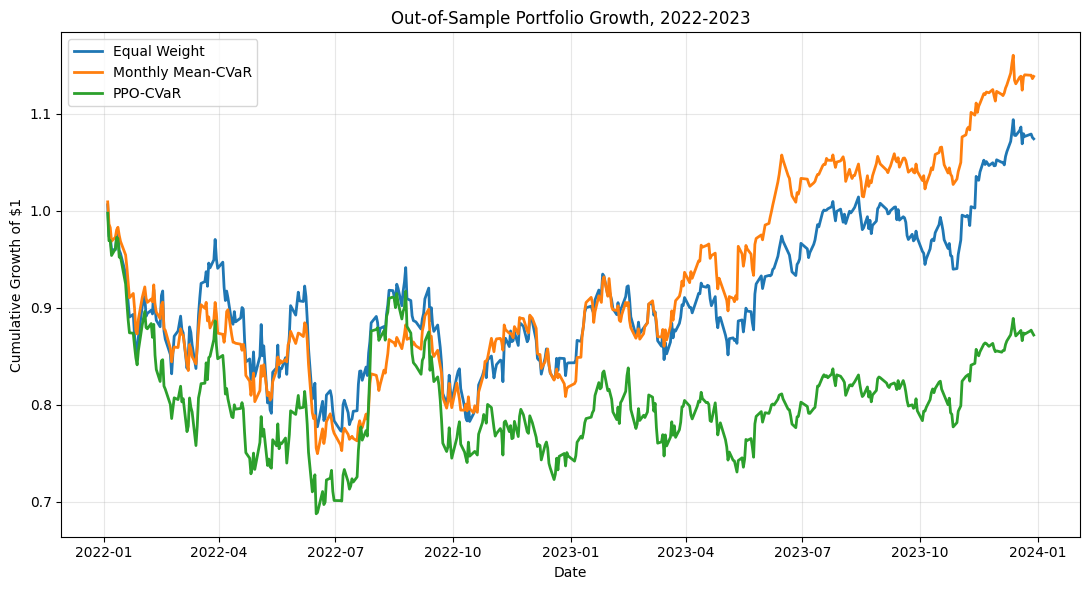

Saved daily strategy results to: p:\IQF Project\data\processed\strategy_daily_results.pkl
Saved metrics to: p:\IQF Project\data\processed\strategy_metrics.csv
Saved plot to: p:\IQF Project\reports\figures\out_of_sample_growth.png


In [13]:
# Plot cumulative out-of-sample growth and save evaluation artifacts.
all_results.to_pickle(PROCESSED_DIR / "strategy_daily_results.pkl")
metrics.to_csv(PROCESSED_DIR / "strategy_metrics.csv")

fig, ax = plt.subplots(figsize=(11, 6))
for strategy, group in all_results.groupby("strategy"):
    group = group.sort_values("date")
    equity = (1.0 + group["portfolio_return"].astype(float)).cumprod()
    ax.plot(group["date"], equity, label=strategy, linewidth=2)

ax.set_title("Out-of-Sample Portfolio Growth, 2022-2023")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth of $1")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "out_of_sample_growth.png", dpi=200)
plt.show()

print(f"Saved daily strategy results to: {PROCESSED_DIR / 'strategy_daily_results.pkl'}")
print(f"Saved metrics to: {PROCESSED_DIR / 'strategy_metrics.csv'}")
print(f"Saved plot to: {FIGURE_DIR / 'out_of_sample_growth.png'}")


## 12. Inspect Final Portfolio Weights

This final table expands PPO weight arrays into stock-level rows so the learned allocations can be included in the report.


In [14]:
# Convert stored PPO weight vectors into a readable long table.
def expand_weight_rows(results: pd.DataFrame, strategy: str = "PPO-CVaR") -> pd.DataFrame:
    rows = []
    subset = results[results["strategy"].eq(strategy)].copy()
    for _, row in subset.iterrows():
        tickers = str(row["tickers"]).split(",")
        weights = np.asarray(row["weights"], dtype=float)
        for ticker, weight in zip(tickers, weights):
            rows.append({
                "date": row["date"],
                "decision_date": row["decision_date"],
                "month": row["month"],
                "strategy": strategy,
                "ticker": ticker,
                "weight": weight,
            })
    return pd.DataFrame(rows)


ppo_weight_table = expand_weight_rows(all_results, "PPO-CVaR")
ppo_weight_table.to_csv(PROCESSED_DIR / "ppo_test_weights.csv", index=False)

display(ppo_weight_table.head(30))
print(f"Saved PPO test weights to: {PROCESSED_DIR / 'ppo_test_weights.csv'}")


,date,decision_date,month,strategy,ticker,weight
0,2022-01-04,2022-01-03,2022-01,PPO-CVaR,POOL,0.028241
1,2022-01-04,2022-01-03,2022-01,PPO-CVaR,MSI,0.018371
2,2022-01-04,2022-01-03,2022-01,PPO-CVaR,ALB,0.112458
3,2022-01-04,2022-01-03,2022-01,PPO-CVaR,NVDA,0.300000
4,2022-01-04,2022-01-03,2022-01,PPO-CVaR,EQR,0.018326
5,2022-01-04,2022-01-03,2022-01,PPO-CVaR,APO,0.049868
6,2022-01-04,2022-01-03,2022-01,PPO-CVaR,DELL,0.074650
7,2022-01-04,2022-01-03,2022-01,PPO-CVaR,ADP,0.106423
8,2022-01-04,2022-01-03,2022-01,PPO-CVaR,MPWR,0.220985
9,2022-01-04,2022-01-03,2022-01,PPO-CVaR,ORCL,0.070678


Saved PPO test weights to: p:\IQF Project\data\processed\ppo_test_weights.csv


## 13. Diagnostics & Validation
### 13.1 – OLS Validation (Equation 1 from Feng et al.)

In [16]:
# 13.1 OLS validation – sentiment predicts next-day return (using FF3 data)
import statsmodels.api as sm

# Use the already-loaded ff3 factors (which contain Mkt_RF and RF)
# ff3 is in daily decimal form; we already have ff3 in the notebook
market_excess = ff3['Mkt_RF']   # already daily
rf_series = ff3['RF']

# overall_score panel (already exists)
sentiment_df = sentiment_panels['overall_score'].stack().reset_index()
sentiment_df.columns = ['date', 'ticker', 'overall_score']

# Returns in long format
ret_df = returns.stack().reset_index()
ret_df.columns = ['date', 'ticker', 'daily_ret']

# Merge sentiment and next-day return
merged = ret_df.merge(sentiment_df, on=['date', 'ticker'], how='inner')
merged['next_day_ret'] = merged.groupby('ticker')['daily_ret'].shift(-1)
merged = merged.dropna(subset=['next_day_ret'])

# Merge market excess on the date the sentiment was observed
merged = merged.merge(market_excess.reset_index(), left_on='date', right_on='Date', how='left')

# Pooled OLS
X = merged[['overall_score', 'Mkt_RF']]
X = sm.add_constant(X)
y = merged['next_day_ret']
model = sm.OLS(y, X).fit()
print(model.summary())

# Same for ESG and SDG scores
for score_name in ['esg_score', 'sdg_score']:
    score_df = sentiment_panels[score_name].stack().reset_index()
    score_df.columns = ['date', 'ticker', score_name]
    merged2 = ret_df.merge(score_df, on=['date', 'ticker'])
    merged2['next_day_ret'] = merged2.groupby('ticker')['daily_ret'].shift(-1)
    merged2 = merged2.dropna(subset=['next_day_ret'])
    merged2 = merged2.merge(market_excess.reset_index(), left_on='date', right_on='Date', how='left')
    X2 = merged2[[score_name, 'Mkt_RF']]
    X2 = sm.add_constant(X2)
    y2 = merged2['next_day_ret']
    model2 = sm.OLS(y2, X2).fit()
    print(f"\n--- {score_name} ---")
    print(f"Coefficient: {model2.params[score_name]:.6f}, p-value: {model2.pvalues[score_name]:.6f}")

                            OLS Regression Results                            
Dep. Variable:           next_day_ret   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     525.6
Date:                Sat, 09 May 2026   Prob (F-statistic):          3.76e-228
Time:                        13:23:18   Log-Likelihood:             3.4657e+05
No. Observations:              143165   AIC:                        -6.931e+05
Df Residuals:                  143162   BIC:                        -6.931e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0007   5.74e-05     11.518

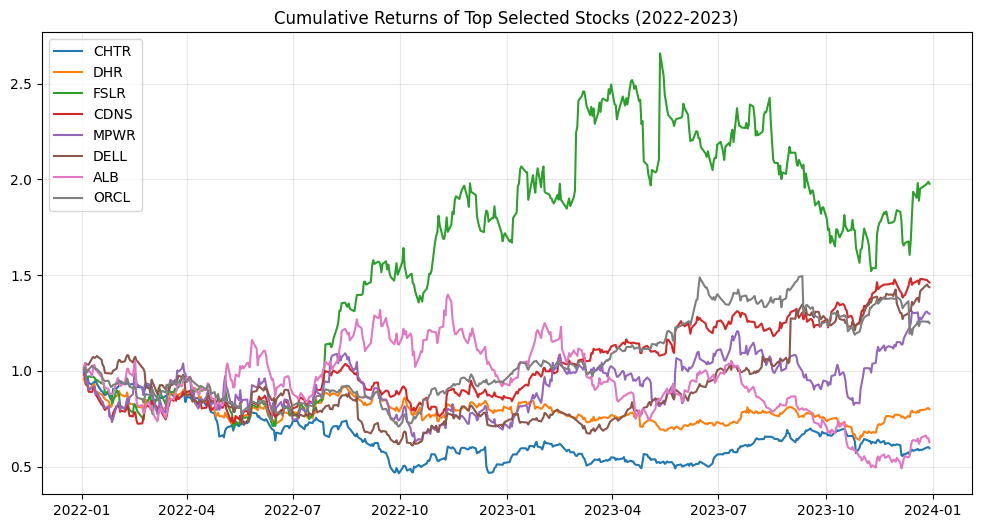

Annualized average return of top-8 most selected stocks in 2022-2023:
CHTR   -0.192615
ALB    -0.100923
POOL   -0.092084
DHR    -0.068752
PNC    -0.042234
HBAN    0.015908
FAST    0.065678
MSI     0.116628
ORCL    0.158285
PH      0.245844
CDNS    0.251222
DELL    0.256397
MPWR    0.282458
NVDA    0.419909
FSLR    0.478775
dtype: float64


In [17]:
# 13.2.1 Performance of stocks that were most frequently selected during training
from collections import Counter

# Count selections in training months (2019-2021)
train_selection_counter = Counter()
for m in train_months:
    train_selection_counter.update(selection_schedule[m])

# Get the 15 most frequently selected tickers during training
most_selected = [ticker for ticker, _ in train_selection_counter.most_common(15)]

# Plot their cumulative returns in the test period (2022-2023)
test_returns = returns.loc[TEST_START:TEST_END, most_selected].copy()
cumulative = (1 + test_returns).cumprod()

plt.figure(figsize=(12, 6))
for t in most_selected[:8]:  # show first 8 for readability
    plt.plot(cumulative.index, cumulative[t], label=t)
plt.title('Cumulative Returns of Top Selected Stocks (2022-2023)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate their average return over entire test period
avg_ret = test_returns.mean() * 252
print("Annualized average return of top-8 most selected stocks in 2022-2023:")
print(avg_ret.sort_values())

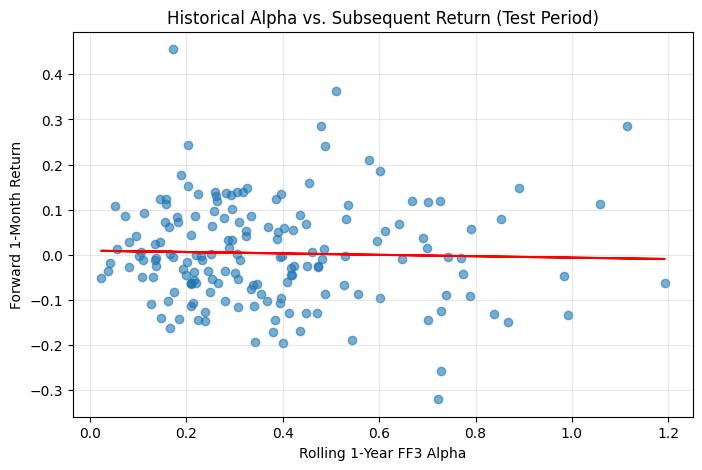

In [18]:
# 13.2.2 Alpha vs. future return for test-period months
test_alpha_snapshot = alpha_3factor.ffill().loc[TEST_START:TEST_END]
test_beta_snapshot = beta_mkt.ffill().loc[TEST_START:TEST_END]

rows = []
for month in test_months:
    month_start = month.start_time
    if month_start not in test_alpha_snapshot.index:
        continue
    tickers = selection_schedule.get(month, [])
    for t in tickers:
        if t in test_alpha_snapshot.columns and t in test_beta_snapshot.columns:
            alpha_val = test_alpha_snapshot.loc[month_start, t]
            beta_val = test_beta_snapshot.loc[month_start, t]
            # compute forward 1-month return
            mask = (returns.index >= month_start) & (returns.index <= month.end_time)
            if mask.sum() > 0:
                fwd_ret = (1 + returns.loc[mask, t]).prod() - 1.0
                rows.append({'alpha': alpha_val, 'beta': beta_val, 'fwd_ret': fwd_ret, 'ticker': t})

diag_df = pd.DataFrame(rows).dropna()
plt.figure(figsize=(8, 5))
plt.scatter(diag_df['alpha'], diag_df['fwd_ret'], alpha=0.6)
plt.xlabel('Rolling 1‑Year FF3 Alpha')
plt.ylabel('Forward 1‑Month Return')
plt.title('Historical Alpha vs. Subsequent Return (Test Period)')
plt.grid(True, alpha=0.3)
# Add regression line
if len(diag_df) > 1:
    m, b = np.polyfit(diag_df['alpha'], diag_df['fwd_ret'], 1)
    plt.plot(diag_df['alpha'], m*diag_df['alpha'] + b, color='red')
plt.show()

In [19]:
# 13.2.3 Volatility-scaled alpha illustration
# Compute idiosyncratic volatility from FF3 residuals
# (We'll approximate with a simpler measure: trailing daily return volatility)
rolling_vol = returns.rolling(252).std().shift(1)   # lag to avoid lookahead
rolling_vol = rolling_vol.loc[TEST_START:TEST_END]

example_month = test_months[6]   # pick e.g. July 2022
month_start = example_month.start_time
if month_start in test_alpha_snapshot.index:
    raw_alpha = test_alpha_snapshot.loc[month_start]
    vol = rolling_vol.loc[month_start]
    valid = raw_alpha.notna() & vol.notna() & (vol > 0)
    scaled_alpha = raw_alpha[valid] / np.sqrt(vol[valid])   # Sharpe-like scaling
    
    # Top-10 by raw alpha vs. top-10 by scaled alpha
    top_raw = raw_alpha.nlargest(10).index.tolist()
    top_scaled = scaled_alpha.nlargest(10).index.tolist()
    
    print(f"Month: {example_month}")
    print("Top-10 by raw alpha:", top_raw)
    print("Top-10 by vol-scaled alpha:", top_scaled)
    
    # Quick performance comparison (forward 1-month return)
    def fwd_ret(tickers, month_start, month_end):
        mask = (returns.index >= month_start) & (returns.index <= month_end)
        return (1 + returns.loc[mask, tickers].mean(axis=1)).prod() - 1.0
    
    m_end = example_month.end_time
    ret_raw = fwd_ret(top_raw, month_start, m_end)
    ret_scaled = fwd_ret(top_scaled, month_start, m_end)
    print(f"Forward 1‑month return: raw-alpha selection = {ret_raw:.4f}, scaled-alpha = {ret_scaled:.4f}")

Month: 2022-07
Top-10 by raw alpha: ['OXY', 'APA', 'MPWR', 'ALB', 'SNPS', 'CDNS', 'VRTX', 'LLY', 'EXC', 'ABBV']
Top-10 by vol-scaled alpha: ['OXY', 'VRTX', 'EXC', 'APA', 'SNPS', 'LLY', 'MPWR', 'ALB', 'CDNS', 'ABBV']
Forward 1‑month return: raw-alpha selection = 0.0994, scaled-alpha = 0.0994


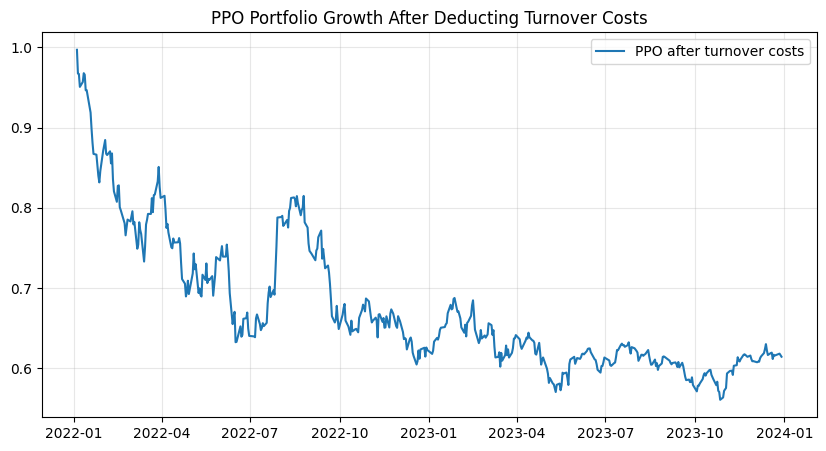

PPO Sharpe with costs: -0.150
PPO Sharpe without costs: 0.562


In [20]:
# 13.3 Turnover cost impact
ppo_daily = all_results[all_results['strategy'] == 'PPO-CVaR'].set_index('date')
ppo_return = ppo_daily['portfolio_return']
turnover_cost = ppo_daily['turnover'] * TRANSACTION_COST
return_after_cost = ppo_return - turnover_cost
equity_after_cost = (1 + return_after_cost).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(equity_after_cost.index, equity_after_cost, label='PPO after turnover costs')
plt.title('PPO Portfolio Growth After Deducting Turnover Costs')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Compare Sharpe with and without costs
sharpe_with = ppo_return.mean() / ppo_return.std() * np.sqrt(252)
sharpe_without = (ppo_return + turnover_cost).mean() / (ppo_return + turnover_cost).std() * np.sqrt(252)
print(f"PPO Sharpe with costs: {sharpe_with:.3f}")
print(f"PPO Sharpe without costs: {sharpe_without:.3f}")

In [22]:
# 13.4 Equal-weight full‑universe portfolio (all available stocks)
rows_ew_full = []
all_tickers = list(returns.columns)
for month in test_months:
    dates = month_decision_dates(returns.index, month, LOOKBACK_RETURNS)
    if not dates:
        continue
    weights = np.ones(len(all_tickers)) / len(all_tickers)
    for decision_date in dates:
        pos = returns.index.get_loc(decision_date)
        next_date = returns.index[pos + 1]
        next_asset_returns = returns.loc[next_date, all_tickers].to_numpy(dtype=float)
        portfolio_return = float(np.dot(weights, next_asset_returns))
        rows_ew_full.append({
            "date": next_date,
            "decision_date": decision_date,
            "month": str(month),
            "strategy": "EW Full Universe",
            "portfolio_return": portfolio_return,
            "turnover": 0.0,
            "tickers": ",".join(all_tickers),
            "weights": weights,
        })
ew_full_results = pd.DataFrame(rows_ew_full)
metrics_ew_full = performance_metrics(ew_full_results)
ew_selected = all_results[all_results['strategy'] == 'Equal Weight']
print("Equal-weight on full universe:")
print(metrics_ew_full)
print("\nEqual-weight on selected 10 (from existing metrics):")
print(metrics[metrics.index == 'Equal Weight'])

Equal-weight on full universe:
annual_return           0.034382
annual_volatility       0.185763
sharpe                  0.274669
sortino                 0.422971
max_drawdown           -0.202585
avg_daily_turnover      0.000000
observations          477.000000
dtype: float64

Equal-weight on selected 10 (from existing metrics):
              annual_return  annual_volatility    sharpe   sortino  max_drawdown  avg_daily_turnover  observations
strategy                                                                                                          
Equal Weight       0.038599           0.251996  0.276396  0.402079     -0.232409                 0.0         477.0
